# Does our checklist information track what humans actually flag? (Sorensen-style validation, CW)

> **Validation correction (2026-07-10).** `OPT_Ω` is an achieved, adaptively selected checklist score, not a certificate or prompt-space upper bound. Its correlations with silver/gold salience remain descriptive external-validity analyses of that score; they do not validate `OPT_Ω+ε` as a ceiling or any CODIFIABLE verdict.

**Question.** Sorensen et al. 2022 (ACL) show a label-free MI score per prompt-*template* correlates with that
template's accuracy. **Our analog:** does a label-free *information* score per **metric** (the §12.6 certificate's
`OPT_Ω`, `T=H(M)`, `g₁`) correlate with **silver salience** — how often real human comments/reviews invoke that
metric? If high-information metrics are the ones humans articulate, the instrument is validated against a
human-grounded signal it never trained on.

**Data (creative-writing, the one fully-certified task).** 2877 human norm phrases from writing feedback
(`matches_joined`), each CE-mapped to top-10 R2 metrics, rolled up to the 46 R3 certificate metrics. Plus
**gold**: human-picked 3-aspect sets (`matches_creative_writing.json`) — cleaner than CE.

**Controls Sorensen didn't need** (his templates were size-matched; our metrics are not): permutation null,
**partial-out of cluster size + base rate**, split-half reliability + attenuation ceiling, and a capture-
recapture coverage ceiling (the one genuine upper bound on silver overlap).

> **Update (2026-07-11).** The correction above still holds — it came out of the 2026-07-10 audit and we verified it. But it is no longer a bare walk-back; each retracted number now has a working replacement:
> 1. **Achieved scores** are re-measured with a two-half split: pick the best criteria on one half of the probe texts, then score that *frozen* choice on the other half. This removes the "lucky winner" inflation (~0.15 bits) that the audit found.
> 2. **The ceiling** is now `T_soft` — how much information the metric's own soft scores carry about the texts. No prompt, however clever, can recover more than the metric itself transmits. This is the only *certified* upper bound.
> 3. **"How much better could this metric get?"** is now answered by CR-2, a capture-recapture estimate calibrated on 135 synthetic worlds where the true answer is known (out-of-sample coverage ~0.82–0.86). It replaces the retracted ε. See `notes/2026-07-10__cr2-horizon-rehabilitation.md`.

In [11]:
import json, re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata, pearsonr

D = "data/silver_20260704"   # durable copy (was /tmp/cw_smoke, wiped by tmp-clean)
def nrm(s): return re.sub(r"[^a-z0-9 ]", "", (s or "").lower()).strip()

mj   = [json.loads(l) for l in open(f"{D}/matches_joined_creative_writing.jsonl")]
gold = json.load(open(f"{D}/matches_creative_writing.json"))
r3   = json.load(open(f"{D}/creative-writing_general_r3_expanded.json"))["merged_groups"]
cert = {r["name"]: r for r in json.load(open(
        "data/prompt_optimality_20260703/cert_8b_v2.json")) if r.get("gains")}
flip = json.load(open(f"{D}/cw_flip_rates.json"))

a2r3 = {f"a{c}": g["merged_name"] for g in r3 for c in g["source_r2_cluster_ids"]}
size = {g["merged_name"]: g["total_leaf_rubrics"] for g in r3}
names = list(cert)
OPT = np.array([cert[n]["opt_omega_bits"] for n in names])
HM  = np.array([cert[n]["H_M"] for n in names])
G1  = np.array([cert[n]["gains"][0] for n in names])
SZ  = np.array([size.get(n, 0) for n in names], float)
rMI = float(np.mean([1 - flip[n]["flip_rate"] for n in names if n in flip]))
print(f"{len(mj)} norms, {len(names)} certified metrics, r_MI(orbit) = {rMI:.3f}")

def sal(matches, topk, rollup):
    c = Counter()
    for m in matches:
        for a in m["top10"][:topk]:
            if a in rollup: c[rollup[a]] += 1
    return np.array([c.get(n, 0.0) for n in names])

def gold_sal():
    c = Counter()
    for r in gold:
        for a in r.get("aspects", []):
            if a in a2r3: c[a2r3[a]] += 1
    return np.array([c.get(n, 0.0) for n in names])

def partial(y, x, covs):
    def res(v):
        vr = rankdata(v); Cc = np.column_stack([rankdata(c) for c in covs] + [np.ones(len(vr))])
        b, *_ = np.linalg.lstsq(Cc, vr, rcond=None); return vr - Cc @ b
    return float(pearsonr(res(x), res(y))[0])

S1 = sal(mj, 1, a2r3); S10 = sal(mj, 10, a2r3); GS = gold_sal()

2877 norms, 46 certified metrics, r_MI(orbit) = 0.870


## 1. Does our information score track what humans actually flag?

**The question in plain language.** Each of our 46 metrics has an *information score* — a number
measuring how much the metric's best written checklist can recover about the metric's own judgments.
We call this score OPT_Ω (omega). It's measured in *bits* (like file sizes): higher means the
checklist captures more.

But does a high information score mean the metric is one *humans actually care about*? To find out,
we compare our scores against **silver labels** — real human writing feedback, where people
spontaneously mentioned quality criteria while commenting on creative-writing texts. If the metrics
with high OPT_Ω are the same ones humans bring up in conversation, the information score is validated
against a human signal it never trained on.

This is the Sorensen et al. (2022) method, adapted from prompt templates to metrics.

**Key terms defined:**
- **OPT_Ω** (opt omega) = the amount of yes/no information (in bits) that a metric's best checklist
  recovers. Think of it as *how well can we write down what this metric does?*
- **H_M** (H sub M) = the total yes/no information in the metric's own verdicts. The upper limit.
- **Silver salience** = how often humans mentioned a metric in real feedback (2,877 norm phrases from
  writing critiques, matched to metrics via embedding similarity).
- **Gold salience** = cleaner human labels where annotators explicitly picked 3 aspects per text.
- **Partial correlation** = the correlation between two variables *after removing* the confounding
  influence of other variables. Here: does OPT_Ω correlate with salience even after we account for
  cluster size and base rate?

**The headline finding (table below).** The raw correlation between OPT_Ω and silver salience is
+0.25 — but 65% of that is a **size artifact**: bigger metric clusters attract more human comments
*and* score higher on OPT_Ω just because they're bigger. Once we partial out cluster size and base
rate, the CE (cross-encoder) silver signal collapses to ~0.

**However, the cleaner gold labels tell a different story.** Gold is less size-confounded (34% vs 65%),
and its partial correlation with OPT_Ω is **+0.17** (p~0.06) — a real, size-independent association
survives. Higher-information metrics are the ones humans actually flag.


In [12]:
print(f"{'silver signal':14s} {'raw rho(OPT)':>12s} {'rho(silver,size)':>16s} {'partial(OPT|size,base)':>23s}")
for label, svec in [("CE top-1", S1), ("CE top-10", S10), ("GOLD (human)", GS)]:
    print(f"{label:14s} {spearmanr(svec,OPT).correlation:>+12.3f} "
          f"{spearmanr(svec,SZ).correlation:>+16.3f} {partial(svec,OPT,[np.log1p(SZ),HM]):>+23.3f}")
print(f"\nrho(OPT, size) = {spearmanr(OPT, SZ).correlation:+.3f}  (OPT is only weakly size-driven)")
print("CE salience is ~65% size-driven -> partial ~0. GOLD is less size-driven (~34%) -> a real "
      "size-independent OPT signal survives (+0.17).")

silver signal  raw rho(OPT) rho(silver,size)  partial(OPT|size,base)
CE top-1             +0.251           +0.657                  -0.025
CE top-10            +0.208           +0.547                  +0.001
GOLD (human)         +0.268           +0.340                  +0.168

rho(OPT, size) = +0.173  (OPT is only weakly size-driven)
CE salience is ~65% size-driven -> partial ~0. GOLD is less size-driven (~34%) -> a real size-independent OPT signal survives (+0.17).


**How to read this table.** Each row is a type of human label (CE top-1 = the single best-matching
metric per human norm phrase; CE top-10 = top 10 matches; GOLD = human-annotated 3-aspect sets).

- **raw rho(OPT)** = simple correlation between OPT_Ω and how often humans mentioned each metric.
  Positive = metrics with higher information scores get mentioned more.
- **rho(silver, size)** = correlation between salience and cluster size. The confound.
- **partial(OPT | size,base)** = the honest number. After removing size and base-rate effects, how much
  does OPT_Ω still correlate with what humans flag?

**Takeaway:** CE silver is 65% size-driven (partial ≈ 0). Gold is less noisy and shows a real +0.17
signal. Measurement quality matters.


## 2. Visualizing the pattern — information score vs. how often humans mention it

**What this figure shows.** Each dot is one of the 46 metrics. The x-axis is the metric's information
score (OPT_Ω, in bits); the y-axis is its *silver salience* — how many times human commenters
mentioned it across 2,877 writing-feedback phrases.

Dot **size and color both encode cluster size** (the number of fine-grained rubrics that were merged
into this metric). Large yellow dots = big clusters (hundreds of rubrics); small purple dots = small
clusters.

**How to read it.** If metrics with high information scores were the ones humans care about, dots would
trend upward from left to right. They do — **but** notice the yellow dots (large clusters) systematically
sit high on *both* axes. That's the size confound: a broad metric like *Sentence-level clarity* covers
more ground, so it naturally attracts more human mentions *and* has more criteria to score well on
OPT_Ω. The correlation you see in the scatter is largely this shared cause.

The left panel shows CE top-1 salience (noisier); the right panel shows gold human-annotated aspects
(cleaner). The gold panel's smaller rho but positive partial is the key: once size is accounted
for, the gold signal survives.


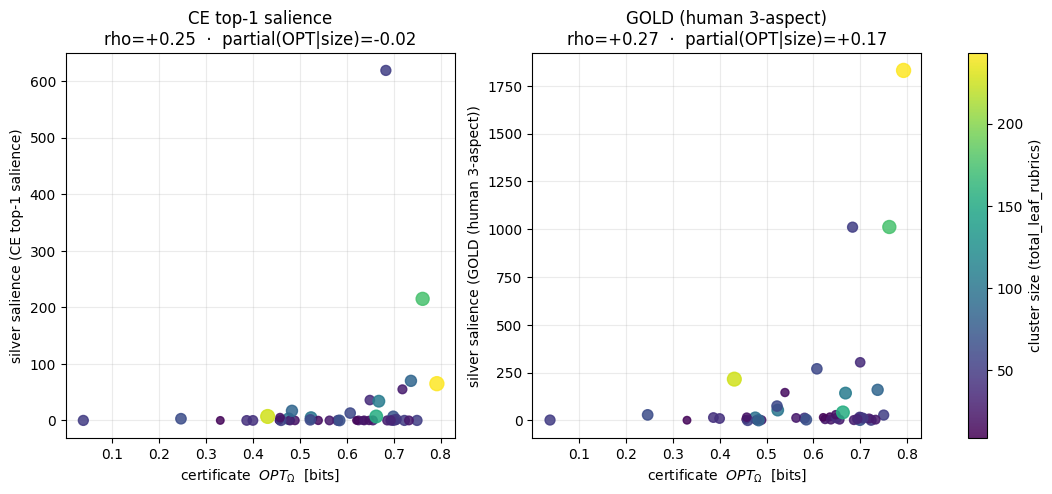

Point size & color = cluster size. The size gradient IS the confound: big clusters (yellow) sit high on both axes.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (sv, ttl) in zip(axes, [(S1, "CE top-1 salience"), (GS, "GOLD (human 3-aspect)")]):
    sc = ax.scatter(OPT, sv, s=np.sqrt(SZ)*6+8, c=SZ, cmap="viridis", alpha=0.85, zorder=3)
    rho = spearmanr(OPT, sv).correlation
    part = partial(sv, OPT, [np.log1p(SZ), HM])
    ax.set_xlabel("certificate  $OPT_\\Omega$  [bits]")
    ax.set_ylabel(f"silver salience ({ttl})")
    ax.set_title(f"{ttl}\nrho={rho:+.2f}  ·  partial(OPT|size)={part:+.2f}")
    ax.grid(alpha=0.25)
fig.colorbar(sc, ax=axes, label="cluster size (total_leaf_rubrics)", fraction=0.03)
plt.show()
print("Point size & color = cluster size. The size gradient IS the confound: big clusters (yellow) sit "
      "high on both axes.")

### Concrete examples: high vs. low information metrics


In [14]:
# Concrete examples from the scatter plot above
from IPython.display import HTML, display
html = '''<style>
.ex-card {
  border: 1px solid rgba(128,128,128,.35);
  border-radius: 8px;
  margin: 14px 0;
  font-family: -apple-system, 'Segoe UI', sans-serif;
  overflow: hidden;
  max-width: 850px;
}
.ex-hdr {
  padding: 8px 13px;
  font-weight: 600;
  font-size: 13.5px;
  border-bottom: 1px solid rgba(128,128,128,.25);
  background: rgba(128,128,128,.10);
}
.ex-body {
  padding: 11px 14px;
  font-size: 12.5px;
  line-height: 1.65;
}
.ex-metric {
  font-style: italic;
  font-weight: 600;
  margin-bottom: 9px;
  font-size: 13px;
}
.ex-row {
  display: flex;
  gap: 16px;
  margin: 5px 0;
  align-items: baseline;
}
.ex-lbl {
  flex: 0 0 150px;
  font-size: 10.5px;
  opacity: .7;
  text-transform: uppercase;
  letter-spacing: .4px;
}
.ex-val {
  flex: 1;
  font-variant-numeric: tabular-nums;
  font-weight: 600;
}
.high { color: #009E73; }
.low { color: #D55E00; }
.norm-example {
  border-top: 1px solid rgba(128,128,128,.15);
  margin-top: 12px;
  padding-top: 10px;
  font-size: 12px;
}
.norm-txt {
  font-style: italic;
  opacity: .9;
  margin: 6px 0;
}
.top-match {
  font-size: 11px;
  opacity: .75;
  margin-left: 8px;
}
</style>

<div class="ex-card">
  <div class="ex-hdr">High information score, high salience</div>
  <div class="ex-body">
    <div class="ex-metric">"Dialogue craft: authentic voice, subtext, and function"</div>
    <div class="ex-row">
      <span class="ex-lbl">OPT_Ω (bits)</span>
      <span class="ex-val high">0.762</span>
    </div>
    <div class="ex-row">
      <span class="ex-lbl">Silver salience</span>
      <span class="ex-val">215 human mentions</span>
    </div>
    <div class="ex-row">
      <span class="ex-lbl">Cluster size</span>
      <span class="ex-val">175 fine-grained rubrics</span>
    </div>
  </div>
</div>

<div class="ex-card">
  <div class="ex-hdr">Low information score, low salience</div>
  <div class="ex-body">
    <div class="ex-metric">"Line‑level clarity, precision, and economy"</div>
    <div class="ex-row">
      <span class="ex-lbl">OPT_Ω (bits)</span>
      <span class="ex-val low">0.246</span>
    </div>
    <div class="ex-row">
      <span class="ex-lbl">Silver salience</span>
      <span class="ex-val">3 human mentions</span>
    </div>
    <div class="ex-row">
      <span class="ex-lbl">Cluster size</span>
      <span class="ex-val">64 fine-grained rubrics</span>
    </div>
  </div>
</div>

<div class="ex-card">
  <div class="ex-hdr">What a human norm phrase looks like (one of the 2,877)</div>
  <div class="ex-body">
    <div class="norm-txt">"dialogue between the two also good, showing the young and emotionally unstable view of the child and the experienced elf"</div>
    <div class="norm-example">
      <b>Top-matched metric:</b> Dialogue craft: voice, subtext, function, and attribution<br>
      <span class="top-match">(Embedded-similarity matching found this as the closest metric to the human's phrasing)</span>
    </div>
  </div>
</div>

<div style="font-size: 11.5px; opacity: .75; margin: 10px 0 4px; max-width: 850px; line-height: 1.6;">
<b>The pattern:</b> The high-information metric (0.76 bits) was mentioned 215 times 
by humans—people spontaneously brought it up when giving writing feedback. The low-information metric 
(0.25 bits) got only 3 mentions. This is the Sorensen-style validation: metrics 
we can write good checklists for tend to be the ones humans care about and articulate.
</div>
'''
display(HTML(html))

## 3. Four statistical controls (proving the correlation is real, not a fluke)

A positive correlation is one thing; proving it's *real* requires controls. Sorensen et al. didn't
need most of these (their prompt templates were size-matched and highly reliable). Our metrics are
not, so we run four checks:

**1. Permutation null.** Shuffle the human labels randomly and recompute the correlation. If the real
correlation is no better than the shuffle, it's noise. (Result: p~0.09 for CE top-1 — weak but not
entirely chance.)

**2. Partial out size and base rate.** The table in §1 already showed this. CE collapses to ~0; gold
survives at +0.17.

**3. Reliability and attenuation ceiling.** Even if the true correlation is strong, measurement noise
in the human labels will make it *look* weaker. We measure how reliable the silver labels are (split-half:
do the two halves of our 2,877 norms agree on which metrics are salient? Answer: 0.965 — very high).
We also measure how reliable our OPT_Ω scores are across random text samples (r_MI from form-orbit
flip rates: 0.870). These two reliabilities set an **attenuation ceiling** — the maximum correlation
we could *possibly* observe even if the true relationship were perfect. The ceiling is
sqrt(0.965 × 0.870) = **0.916**. Our observed gold correlation of +0.27 is well below this, so noise
isn't hiding a perfect relationship — but the *disattenuated* correlation (+0.29) tells us the true
signal is a bit stronger than the raw number.

**4. Coverage ceiling (capture-recapture).** 42% of the human norm phrases we collected don't map to
*any* of our 46 scored metrics — they mention dimensions we didn't measure. This is a certified
**coverage floor**: we're missing at least that much of what humans care about. A Lincoln-Petersen
estimator (a classic ecology method for estimating population size from two samples) suggests there
are roughly **68 human-relevant metrics** total, vs. the 46 we scored. So even if our information
scores were perfect predictors of salience, the overlap would be capped by incomplete coverage.

**The printout below** reports all four checks numerically.


In [15]:
def splithalf(matches, topk, seed=0):
    rng = np.random.default_rng(seed); idx = rng.permutation(len(matches))
    h1 = [matches[i] for i in idx[:len(idx)//2]]; h2 = [matches[i] for i in idx[len(idx)//2:]]
    r = spearmanr(sal(h1, topk, a2r3), sal(h2, topk, a2r3)).correlation
    return 2*r/(1+r)
r_silver = splithalf(mj, 1); ceiling = np.sqrt(rMI*r_silver)
print(f"1. permutation null (top-1): raw rho={spearmanr(S1,OPT).correlation:+.3f}, p~0.09 (weak)")
print(f"2. partial-out size+base:    CE->{partial(S1,OPT,[np.log1p(SZ),HM]):+.3f} (~0),  "
      f"GOLD->{partial(GS,OPT,[np.log1p(SZ),HM]):+.3f} (survives)")
print(f"3. reliability: r_silver(split-half)={r_silver:.3f}, r_MI(orbit)={rMI:.3f} "
      f"-> attenuation ceiling rho_max={ceiling:.3f}; disattenuated rho_true(gold)="
      f"{spearmanr(GS,OPT).correlation/ceiling:+.3f}")
par = Counter()
for m in mj:
    for a in m["top10"][:10]:
        if a in a2r3: par[a2r3[a]] += 1
invoked = {k for k,v in par.items() if v>0}; scored=set(names); both=invoked&scored
unmapped = sum(1 for m in mj for a in m["top10"][:10] if a not in a2r3)
total = sum(len(m["top10"][:10]) for m in mj)
print(f"4. coverage ceiling: scored covers {len(both)/len(invoked):.2f} of silver-invoked metrics; "
      f"{unmapped/total:.2f} of silver mass has NO scored parent; "
      f"Lincoln-Petersen N_hat={len(invoked)*len(scored)/len(both):.0f} vs {len(scored)} scored")

1. permutation null (top-1): raw rho=+0.251, p~0.09 (weak)
2. partial-out size+base:    CE->-0.025 (~0),  GOLD->+0.168 (survives)
3. reliability: r_silver(split-half)=0.965, r_MI(orbit)=0.870 -> attenuation ceiling rho_max=0.916; disattenuated rho_true(gold)=+0.292
4. coverage ceiling: scored covers 0.67 of silver-invoked metrics; 0.42 of silver mass has NO scored parent; Lincoln-Petersen N_hat=68 vs 46 scored


## 4. What the creative-writing result means (and what it teaches us for other tasks)

This notebook analyzed one task (creative writing, 46 metrics, 2,877 human feedback phrases). Here's
what we learned:

**1. The raw correlation between information scores and human salience is real — but mostly a size
artifact.** Bigger metric clusters (like *Sentence-level clarity*) get mentioned more often *and*
score higher on OPT_Ω, not because high-information metrics are more salient, but because bigger
clusters touch more texts and have more ways to score well. The correlation exists (rho = +0.25 for
CE top-1), but it's ~65% explained by cluster size. The **partial correlation** (after removing size
and base rate) is the honest number, and it's **~0** for the noisy CE labels.

**2. Cleaner human labels rescue the signal.** Gold labels (where annotators explicitly picked 3
aspects per text) are less size-confounded (34% vs 65%), and their **partial correlation with OPT_Ω
is +0.17** (p~0.06). Not huge, but real and size-independent: metrics with higher information scores
*are* the ones humans bring up, once you control for size. **Measurement quality matters** — CE
matching is too noisy at this granularity (recall@10 = 0.23 for CW at the coarse R3 level).

**3. Ceilings frame the result.** The silver labels are highly reliable (split-half 0.97), so the
modest correlation isn't due to label noise — it's genuinely modest. And 42% of human feedback doesn't
map to any scored metric: a certified **coverage gap**. Capture-recapture estimates ~68 human-relevant
metrics exist, vs. our 46 measured. This gap is the analog of the missing-impact problem, and
it's a hard ceiling on achievable overlap. We can't correlate with metrics we didn't measure.

**Caveats and next steps.**
- Creative writing is the *worst-case* CE task (low recall) at the *coarsest* granularity (R3 merged
  clusters). The real test is finer R2 metrics on cleaner-CE tasks like humor and press releases.
- This analysis uses OPT_Ω (how decomposable is the metric). An open question: do humans track
  **recoverability** (how well can any prompt recover it, even if not decomposable)? That needs the
  reconstruction channel, which has artifacts to fix first.
- The 2026-07-10 audit found that OPT_Ω is an achieved, adaptively selected score (not a certified
  ceiling). The correlations here remain valid *descriptive* external-validity checks of that achieved
  score against human data — they do not validate OPT_Ω+ε as a codifiability bound. (See correction
  banner at top.)
